# 1 Bias variance Trade-off of Ridged regression

We have a linear model of the form $y = X\beta + \epsilon$

Now we ridge estimator is the following:

$$
\hat{\beta}_{\text{ridge}} = (X^T X + \lambda I)^{-1} X^T y
$$


Now we calcualte the squared error for this point
$$ (\hat{y_{0}}-y_{0})^2 = (x_{0}^T\hat{\beta}_{\text{ridge}} - x_{0}^T\beta) ^2 + ϵ_{0}$$

$$
\mathbb{E}[\hat{\beta}_{\text{ridge}}] = (X^T X + \lambda I)^{-1} X^T X \beta
$$

And now we can calculate the bias of the coefficent estimate

$$ Bias[\hat{\beta}_{\text{ridge}}] = \mathbb{E}[\hat{\beta}_{\text{ridge}}] - \hat{\beta}_{\text{ridge}} = ((X^T X + \lambda I)^{-1} X^T X - I)\beta
$$

Now we will calculate the variance of the $\hat{\beta}_{\text{ridge}}$

$$
\mathrm{Var}(\hat{\beta}_{\text{ridge}}) = \sigma^2 (X^T X + \lambda I)^{-1} X^T X (X^T X + \lambda I)^{-1}
$$

Now as $\lambda$ increases we get that the term $(X^T X + \lambda I) $ becomes more diagonal and therefore $(X^T X + \lambda I)^{-1} $ becomes smaller. Therefore when we increase $\lambda$ the variance will become 0 however the magnitude of the bias will increase. On the other hand if $\lambda$ will decrease the bias will be closer to 0 and the variance will become bigger.


Now we will find the $\lambda$ that gives the minimum value. we will calculate the MSE of the coefficients

$$
\sum_{j=1}^{p} \mathbb{E}\left(\frac{1}{1+\lambda} \hat{\beta}_j - \beta_j \right)^2 = \left(\frac{1}{1+\lambda}\right)^2 \sum_{j=1}^{p} \mathbb{E} \left(\hat{\beta}_j - \beta_j \right)^2 + \left(\frac{\lambda}{1+\lambda}\right)^2 \sum_{j=1}^{p} \beta_j^2
$$

$$
= p \sigma^2 \left(\frac{1}{1+\lambda}\right)^2 + \left(\frac{\lambda}{1+\lambda}\right)^2 \sum_{j=1}^{p} \beta_j^2
$$

After taking the derivative and making everythign equal to 0, we get that the $\alpha$ with the smallest MSE is the following

$$
\lambda^* = \frac{p \sigma^2}{\sum_{j=1}^{p} \beta_j^2}
$$



# 2 Beyond quadratic loss

The integraldepends on the value of $\alpha\ $ to calculate the optimal value. This optimal value is the minimizer of the $L_{1}$ loss. This happens then $α$ is equal to the median of y cause then the probability mass function on both the left and the right are equal therefore we would have the smallest loss the

Financial interpretation: The difference in the predicted and actual price of a stock at time T given the price at time t is the smallest when the prediction is the median value of the stock price across all possible periods of time available

If we had x in multiple dimensions, when y would need to be calculated based on the point where it has a geometric median across all dimensions, which is possible and it will not change the actual definition.

# Part 3 Feature Engineering on hedge fund dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

folder_path = '/content/drive/MyDrive/MLCS-HW3'
if os.path.exists(folder_path):
    print(f"Files in {folder_path}:")
    for file_name in os.listdir(folder_path):
        print(file_name)
else:
    print(f"Folder not found: {folder_path}")

Files in /content/drive/MyDrive/MLCS-HW3:
F-F_Research_Data_5_Factors_2x3.csv
FundReturns (1).xlsx


In [ ]:
import pandas as pd

fama_file_path = os.path.join(folder_path, "F-F_Research_Data_5_Factors_2x3.csv")
fama = pd.read_csv(fama_file_path, skiprows=3)

fund_returns_file_path = os.path.join(folder_path, "FundReturns (1).xlsx")
fund_returns = pd.read_excel(fund_returns_file_path)

In [ ]:
# Fama has both monthly and early data so we split it into monthly and yearly.

fama_monthly = fama[fama.iloc[:, 0].astype(str).str.len() == 6].copy()
fama_early = fama[fama.iloc[:, 0].astype(str).str.len() == 4].copy()

display(fama_monthly.head())
display(fama_early.head())

,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
0,196307,-0.39,-0.48,-0.81,0.64,-1.15,0.27
1,196308,5.08,-0.80,1.70,0.40,-0.38,0.25
2,196309,-1.57,-0.43,0.00,-0.78,0.15,0.27
3,196310,2.54,-1.34,-0.04,2.79,-2.25,0.29
4,196311,-0.86,-0.85,1.73,-0.43,2.27,0.27


,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
746,1964,12.59,0.40,9.82,-2.59,6.64,3.54
747,1965,10.52,24.71,7.42,-0.86,-3.85,3.93
748,1966,-13.55,2.33,-0.83,-0.40,-0.78,4.76
749,1967,24.51,50.18,-8.06,9.06,-15.84,4.21
750,1968,8.91,26.25,18.23,-13.90,16.87,5.21


In [ ]:
display(fama_monthly.head())
display(fama_monthly.tail())
display(fund_returns.head())
display(fund_returns.tail())

,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
0,196307,-0.39,-0.48,-0.81,0.64,-1.15,0.27
1,196308,5.08,-0.80,1.70,0.40,-0.38,0.25
2,196309,-1.57,-0.43,0.00,-0.78,0.15,0.27
3,196310,2.54,-1.34,-0.04,2.79,-2.25,0.29
4,196311,-0.86,-0.85,1.73,-0.43,2.27,0.27


,Unnamed: 0,Mkt-RF,SMB,HML,RMW,CMA,RF
739,202502,-2.43,-4.91,4.91,1.10,3.06,0.33
740,202503,-6.39,-1.49,2.90,2.11,-0.47,0.34
741,202504,-0.84,-1.86,-3.40,-2.85,-2.67,0.35
742,202505,6.06,-0.72,-2.88,1.26,2.51,0.38
743,202506,4.86,-0.02,-1.60,-3.19,1.45,0.34


,Unnamed: 0,Fund
0,196307,0.012244
1,196308,0.621265
2,196309,0.046781
3,196310,0.406114
4,196311,-0.014780


,Unnamed: 0,Fund
739,202502,-0.122091
740,202503,-0.149787
741,202504,-0.221177
742,202505,0.469441
743,202506,0.207997


In [ ]:
# Ensure both fama_monthly and fund_returns DataFrames have a proper datetime index for time-series analysis.

fama_monthly['Unnamed: 0'] = pd.to_datetime(fama_monthly['Unnamed: 0'], format='%Y%m')
fama_monthly.set_index('Unnamed: 0', inplace=True)

fund_returns['Unnamed: 0'] = pd.to_datetime(fund_returns['Unnamed: 0'], format='%Y%m')
fund_returns.set_index('Unnamed: 0', inplace=True)

display(fama_monthly.head())
display(fund_returns.head())

,Mkt-RF,SMB,HML,RMW,CMA,RF
Unnamed: 0,,,,,,
1963-07-01,-0.39,-0.48,-0.81,0.64,-1.15,0.27
1963-08-01,5.08,-0.80,1.70,0.40,-0.38,0.25
1963-09-01,-1.57,-0.43,0.00,-0.78,0.15,0.27
1963-10-01,2.54,-1.34,-0.04,2.79,-2.25,0.29
1963-11-01,-0.86,-0.85,1.73,-0.43,2.27,0.27


,Fund
Unnamed: 0,
1963-07-01,0.012244
1963-08-01,0.621265
1963-09-01,0.046781
1963-10-01,0.406114
1963-11-01,-0.014780


In [ ]:
# Combine the data
combined_data = pd.concat([fama_monthly, fund_returns], axis=1)
display(combined_data.head())

,Mkt-RF,SMB,HML,RMW,CMA,RF,Fund
Unnamed: 0,,,,,,,
1963-07-01,-0.39,-0.48,-0.81,0.64,-1.15,0.27,0.012244
1963-08-01,5.08,-0.80,1.70,0.40,-0.38,0.25,0.621265
1963-09-01,-1.57,-0.43,0.00,-0.78,0.15,0.27,0.046781
1963-10-01,2.54,-1.34,-0.04,2.79,-2.25,0.29,0.406114
1963-11-01,-0.86,-0.85,1.73,-0.43,2.27,0.27,-0.014780


In [ ]:
for col in combined_data.columns:
    combined_data[col] = pd.to_numeric(combined_data[col], errors='coerce')

mean_values = combined_data.mean()
std_values = combined_data.std()
skew_values = combined_data.skew()
kurtosis_values = combined_data.kurtosis()
max_values = combined_data.max()
min_values = combined_data.min()

summary_statistics = pd.DataFrame({
    'Mean': mean_values,
    'Std Dev': std_values,
    'Skewness': skew_values,
    'Kurtosis': kurtosis_values,
    'Max': max_values,
    'Min': min_values
})

display(summary_statistics)

,Mean,Std Dev,Skewness,Kurtosis,Max,Min
Mkt-RF,0.587352,4.474805,-0.497931,1.714173,16.10000,-23.190000
SMB,0.177863,3.031835,0.361580,3.076145,18.46000,-15.540000
HML,0.281882,2.972221,0.099278,2.221190,12.86000,-13.830000
RMW,0.274664,2.219306,-0.317537,11.232867,13.05000,-18.950000
CMA,0.249852,2.060815,0.274050,1.408035,9.01000,-7.080000
RF,0.363656,0.262525,0.658625,0.769275,1.35000,0.000000
Fund,0.098728,0.353964,-0.254167,0.729610,1.22995,-1.463161


*Perform the OLS*

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Add a constant to the independent variables for the intercept
X = sm.add_constant(combined_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']])
y = combined_data['Fund']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# Reset indices to align after splitting
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


# Perform the OLS regression
model = sm.OLS(y_train, X_train).fit()


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

# Print the regression summary
print(model.summary())

MSE: 0.03217813547593425
                            OLS Regression Results                            
Dep. Variable:                   Fund   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     346.4
Date:                Tue, 30 Sep 2025   Prob (F-statistic):          2.55e-189
Time:                        03:02:31   Log-Likelihood:                 217.29
No. Observations:                 595   AIC:                            -420.6
Df Residuals:                     588   BIC:                            -389.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0323      

Doing the elastic net

In [ ]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=1.0, l1_ratio=0.5)

model.fit(X_train, y_train)
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Iterations:', model.n_iter_)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

Coefficients: [ 0.         0.0427923  0.         0.         0.         0.
 -0.       ]
Intercept: 0.06897328698551575
Iterations: 2
MSE: 0.043114536823554865


We observe that the Elastic Net model has only 1 non zero coeficient and the ols has all the coefficents non Zero. OLS has a MSE of 0.03 and Elastic Net has a MSE of 0.04 which are similar in comparison with OLS having the better model

Part B Adding atleast 10 more non linear regressors





In [ ]:
import numpy as np

combined_data['log_Mkt_RF'] = np.log(np.abs(combined_data['Mkt-RF']) + 1)
combined_data['SMB_times_HML'] = combined_data['SMB'] * combined_data['HML']
combined_data['log_RMW'] = np.log(np.abs(combined_data['RMW']) + 1)
combined_data['log_CMA'] = np.log(np.abs(combined_data['CMA']) + 1)
combined_data['log_RF'] = np.log(np.abs(combined_data['RF']) + 1)
combined_data['CMA_squared'] = combined_data['CMA'] ** 2
combined_data['SMB_times_log_RF'] = combined_data['SMB'] * np.log(np.abs(combined_data['RF']) + 1)
combined_data['log_HML_times_RMW'] = np.log(np.abs(combined_data['HML']) + 1) * combined_data['RMW']
combined_data['Mkt_RF_squared'] = combined_data['Mkt-RF'] ** 2
combined_data['HML_times_CMA'] = combined_data['HML'] * combined_data['CMA']


Perform the Elastic Net model on the new dataset

In [ ]:
# Add a constant to the independent variables for the intercept
X = sm.add_constant(combined_data[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']])
y = combined_data['Fund']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

# Reset indices to align after splitting
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


model = ElasticNet(alpha=1.0, l1_ratio=0.5)

model.fit(X_train, y_train)
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Iterations:', model.n_iter_)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

Coefficients: [ 0.         0.0427923  0.         0.         0.         0.
 -0.       ]
Intercept: 0.06897328698551575
Iterations: 2
MSE: 0.043114536823554865


OLS MSE scores: [0.03470234 0.02485112 0.0222255  0.02743652 0.03694447 0.02746556
 0.02462326 0.03203206 0.03584958 0.0241801 ]
OLS MSE mean: 0.029031051910156508
OLS MSE std: 0.00511883890100048
Elastic Net MSE scores: [0.05116142 0.0449526  0.04595211 0.04625449 0.0441476  0.04389545
 0.03963107 0.04828145 0.06140854 0.03948928]
Elastic Net MSE mean: 0.046517399240519106
Elastic Net MSE std: 0.00598806031363289


/tmp/ipython-input-2626505275.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ols_mse_scores, enet_mse_scores], labels=['OLS', 'Elastic Net'])


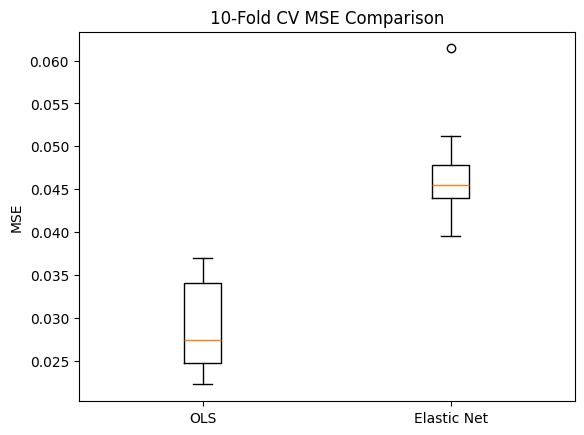

/tmp/ipython-input-2626505275.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ols_mse_scores, enet_mse_scores], labels=['OLS', 'Elastic Net'])


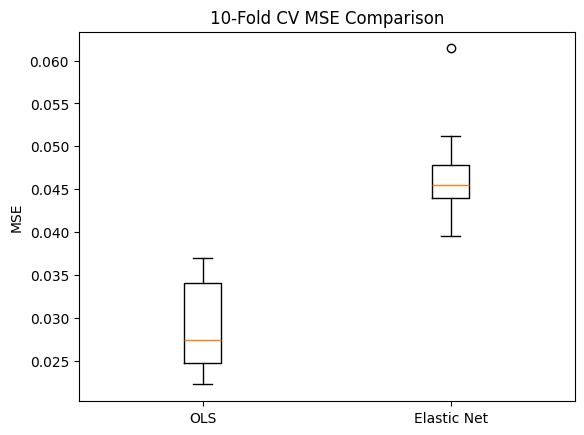

In [ ]:
# 10 fold cross validation

from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

cv = KFold(n_splits=10, shuffle=True, random_state=42)

# OLS cross validation
ols = LinearRegression()
ols_mse_scores = -cross_val_score(ols, X_train, y_train, scoring='neg_mean_squared_error', cv=cv)
print('OLS MSE scores:', ols_mse_scores)
print('OLS MSE mean:', np.mean(ols_mse_scores))
print('OLS MSE std:', np.std(ols_mse_scores))




# Elastic net cross validation
enet = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
enet_mse_scores = -cross_val_score(enet, X_train, y_train, scoring='neg_mean_squared_error', cv=cv)
print('Elastic Net MSE scores:', enet_mse_scores)
print('Elastic Net MSE mean:', np.mean(enet_mse_scores))
print('Elastic Net MSE std:', np.std(enet_mse_scores))

# Compare the distributions
import matplotlib.pyplot as plt
plt.boxplot([ols_mse_scores, enet_mse_scores], labels=['OLS', 'Elastic Net'])
plt.ylabel('MSE')
plt.title('10-Fold CV MSE Comparison')
plt.show()



OLS has a lower MSE that ElasticNet therefore it is a better estimator. Also the MSE decreased from 0.04 to 0.025 so we have a better improvement. Similarly the variance decreased as the box plot is smaller therefore making more folds does indead make the model have a smaller bias and variance

In [ ]:
# Use grid search to compare

import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': np.logspace(-4, 2, 10),      # e.g., 0.0001 to 100
    'l1_ratio': np.linspace(0, 1, 10)     # 0 (Ridge) to 1 (Lasso)
}

enet = ElasticNet(max_iter=10000, random_state=42)
grid = GridSearchCV(enet, param_grid, scoring='neg_mean_squared_error', cv=10)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best cross-validated MSE:', -grid.best_score_)

y_pred = grid.predict(X_test)
from sklearn.metrics import mean_squared_error
mse_test = mean_squared_error(y_test, y_pred)
print('Test set MSE:', mse_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.286e+00, tolerance: 6.640e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.608e+00, tolerance: 6.866e-03 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

Best parameters: {'alpha': np.float64(0.002154434690031882), 'l1_ratio': np.float64(0.8888888888888888)}
Best cross-validated MSE: 0.02883954104760018
Test set MSE: 0.032169667096518695


The best model has the following features: 'alpha': np.float64(0.002154434690031882), 'l1_ratio': np.float64(0.8888888888888888) and they are the best in terms of MSE of the test set because the lowest bias and variance it would also be the lowest in mse as MSE = bias^2 + variance + nosie